<a href="https://colab.research.google.com/github/jackhobday/nba-game-predictor/blob/main/nba_game_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/jackhobday/nba-game-predictor/blob/main/nba_game_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Git Repo**: https://github.com/jackhobday/nba-game-predictor

What will be your goal in working on this project?

*   My goal is to use previous results from NBA games, along with the season-long stats of each team at the time of the game, to predict the outcomes of future games.


What will be your source for data for the project? If this requires you to gather data, how will you go about this?


*   My data source is going to be https://www.basketball-reference.com/. I'll have to save all the data tables I need into csv's and then upload the complete data set to my personal Git repo.


What data cleaning, conversion, or preparation will you need to do to prepare your data set?


* To create my dataset I will take game logs from every NBA team from 2015-2025. Once I have these I will merge the two game logs from each game into one row which will have game level data, as well as, advanced stats from the game for both teams. Using the stats from each game I can start to build season-level features which will have the teams advanced stats like offensive rating and efficiency up until the point of the game I will try to predict. For each row in the final game-level data set each row will contain game outcome, home and away teams, season-to-date metrics for each teams, and any other features I decide to include.

What kinds of exploratory data analysis will you do?


*   I'll want to look at baseline home vs. away winning percentage, as well as, average performance metrics for teams at home versus away to try to quantify home field advantage. I'll also look at the distribution of the stat features using histograms and box plots.


Which machine learning algorithms will you use to train models? Why are you choosing these algorithms?


*   I will use **XGBoost** for both classification and regression approaches. XGBoost is well-suited for this problem because:
  - It handles high complexity data sets with lots of features
  - It can capture non-linear relationships between features
  - It provides built-in regularization to prevent overfitting
  - It offers feature importance scores to understand model decisions
  - It performs well with time-series cross-validation setups
  
  I will train two models:
  1. **XGBoost Classifier**: Directly predicts win/loss (binary classification)
  2. **XGBoost Regressor**: Predicts point differential, then converts to win/loss predictions


How will you attempt to optimize your models?


*   I will optimize the models using several techniques:
  - **Time-series cross-validation**: Rolling season splits (train on 2015-2020, test on 2021+)
  - **Sample weighting**: Apply exponential decay weighting to give more importance to recent seasons (decay factor = 0.10)
  - **Early stopping**: Use validation set to prevent overfitting and find optimal number of boosting rounds
  - **Hyperparameter tuning**: Use conservative parameters (eta=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8) to balance performance and generalization
  - **Feature engineering**: Create differential features (Team stat - Opponent stat) to capture matchup advantages


How will you analyze the accuracy of your models?


*   I will evaluate model performance using multiple metrics:
  - **Classification metrics**: Accuracy (percentage of correct predictions) and ROC-AUC (area under the receiver operating characteristic curve)
  - **Regression metrics** (for regressor): RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² (coefficient of determination)
  - **Cross-validation results**: Average performance across multiple test seasons (2020-21 through 2025-26)
  - **Feature importance analysis**: Identify which features contribute most to predictions
  - **Comparison**: Compare classifier vs. regressor approaches to determine which performs better




## **1. Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [2]:
# Load in dataset
pd.set_option('display.max_columns', None)
df = pd.read_csv('https://raw.githubusercontent.com/jackhobday/nba-game-predictor/main/data_merged/games_all_seasons.csv')
df.head(20)

,Season,Date,Team,Opponent,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Points_For_avg,Team_Points_Against_avg,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Points_For_avg,Opp_Points_Against_avg,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
0,2015-16,2015-10-27,ATL,DET,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,94,106,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2015-16,2015-10-27,CHI,CLE,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,97,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2015-16,2015-10-27,GSW,NOP,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,111,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2015-16,2015-10-28,BKN,CHI,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,97.0,95.0,2.0,100.0,1.0,0.47,11.8,15.2,0.18,0.50,48.5,35.1,6.0,15.4,2.0,2.0,1.0,1.0,97.0,95.0,1,0,NaN,0.0,1,0,100,115,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,-1
4,2015-16,2015-10-28,BOS,PHI,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,112,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,2015-16,2015-10-28,CHA,MIA,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,94,104,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,2015-16,2015-10-28,CLE,MEM,0,2,1,95.0,97.0,-2.0,100.0,0.0,0.45,9.8,21.6,0.11,0.47,51.5,68.4,5.0,10.3,-2.0,-2.0,0.0,0.0,95.0,97.0,0,1,NaN,0.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,106,76,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
7,2015-16,2015-10-28,DAL,PHX,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,111,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,2015-16,2015-10-28,DEN,HOU,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,105,85,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
9,2015-16,2015-10-28,DET,UTA,1,2,1,111.2,98.6,12.6,95.3,1.0,0.45,12.3,41.1,0.21,0.49,59.6,62.2,5.2,5.5,12.6,12.6,1.0,1.0,106.0,94.0,1,0,0.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
print(df.columns)

Index(['Season', 'Date', 'Team', 'Opponent', 'Is_Home', 'Game_Number_Team',
       'Game_Number_Opp', 'Team_ORtg_avg', 'Team_DRtg_avg', 'Team_NetRtg_avg',
       'Team_Pace_avg', 'Team_WinPct_avg', 'Team_eFG%_avg', 'Team_TOV%_avg',
       'Team_ORB%_avg', 'Team_FT/FGA_avg', 'Team_TS%_avg', 'Team_TRB%_avg',
       'Team_AST%_avg', 'Team_STL%_avg', 'Team_BLK%_avg', 'Team_NetRtg_last5',
       'Team_NetRtg_last10', 'Team_WinPct_last5', 'Team_WinPct_last10',
       'Team_Points_For_avg', 'Team_Points_Against_avg',
       'Team_Current_Win_Streak', 'Team_Current_Loss_Streak',
       'Team_Home_WinPct', 'Team_Away_WinPct', 'Team_Days_Rest',
       'Team_Is_BackToBack', 'Opp_ORtg_avg', 'Opp_DRtg_avg', 'Opp_NetRtg_avg',
       'Opp_Pace_avg', 'Opp_WinPct_avg', 'Opp_eFG%_avg', 'Opp_TOV%_avg',
       'Opp_ORB%_avg', 'Opp_FT/FGA_avg', 'Opp_TS%_avg', 'Opp_TRB%_avg',
       'Opp_AST%_avg', 'Opp_STL%_avg', 'Opp_BLK%_avg', 'Opp_NetRtg_last5',
       'Opp_NetRtg_last10', 'Opp_WinPct_last5', 'Opp_WinPc

## **2. EDA**

In [4]:
# Basic statistical measures
df.describe()

,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Points_For_avg,Team_Points_Against_avg,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Points_For_avg,Opp_Points_Against_avg,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
count,12590.00000,12590.000000,12590.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12590.000000,12590.000000,6295.000000,6295.000000,12590.000000,12590.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.00000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12425.000000,12590.000000,12590.000000,6295.000000,6295.000000,12590.000000,12590.000000,12590.000000,12590.000000,12590.000000,12590.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12414.000000,12590.000000,12590.000000
mean,0.50000,39.623352,39.571962,110.663497,110.420163,0.243352,98.834744,0.506722,0.527751,12.913104,23.306744,0.202979,0.563595,49.987062,60.213179,7.796658,8.916934,0.162799,0.184741,0.504790,0.505031,110.066173,109.819538,1.156791,1.119301,0.559963,0.424662,2.210723,0.013106,110.368795,110.566680,-0.197874,98.803665,0.49463,0.525842,12.957476,23.412625,0.204118,0.562048,50.021928,59.503769,7.845792,9.096491,-0.142781,-0.155132,0.495741,0.495758,109.728261,109.929541,1.129865,1.230818,0.546307,0.415938,2.211914,0.013106,110.727641,110.359492,0.509770,0.054805,0.441061,0.295076,-0.145979,0.012264,0.305295,0.009219,0.339618,0.009443,0.001924,-0.044226,-0.110662,-0.001093,0.030527,-0.001191,0.026926
std,0.50002,23.218873,23.209125,5.343864,4.817434,5.665759,2.679397,0.181181,0.028514,1.237529,3.020413,0.027058,0.026753,1.912281,4.618513,1.080225,1.727632,8.062305,6.804453,0.261325,0.217571,6.489212,6.149351,1.817045,1.857092,0.230597,0.215433,4.298202,0.113732,5.055436,5.097405,5.860984,2.826410,0.18285,0.026242,1.232778,3.129579,0.028306,0.024931,1.993553,4.923613,1.078305,1.688924,8.216167,7.044108,0.265789,0.222610,6.384473,6.711023,1.838906,2.062824,0.235724,0.214072,4.292197,0.113732,13.226793,12.784237,0.499924,0.227609,8.168784,5.648657,5.256247,0.258875,11.662930,0.378830,9.857664,0.314698,0.032246,1.656073,4.142464,0.036222,3.176249,2.074645,2.601897
min,0.00000,1.000000,1.000000,84.600000,83.000000,-32.900000,89.600000,0.000000,0.390000,3.900000,9.300000,0.060000,0.420000,35.200000,32.400000,1.800000,0.000000,-32.900000,-32.900000,0.000000,0.000000,85.000000,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.200000,76.200000,-48.200000,89.600000,0.00000,0.340000,5.700000,5.900000,0.030000,0.390000,32.900000,34.700000,2.200000,0.000000,-48.200000,-48.200000,0.000000,0.000000,76.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,68.

### Feature Engineering Overview

The dataset contains engineered features that capture team performance, recent form, and matchup dynamics. Features are calculated **before** each game to prevent data leakage. The features fall into several categories:

#### 1. **Team Season-to-Date Statistics** (Cumulative averages)
- **Offensive/Defensive Ratings**: `Team_ORtg_avg`, `Team_DRtg_avg`, `Team_NetRtg_avg`
- **Advanced Metrics**: `Team_eFG%_avg`, `Team_TS%_avg`, `Team_TOV%_avg`, `Team_ORB%_avg`, `Team_FT/FGA_avg`
- **Other Stats**: `Team_Pace_avg`, `Team_TRB%_avg`, `Team_AST%_avg`, `Team_STL%_avg`, `Team_BLK%_avg`
- **Win Percentage**: `Team_WinPct_avg`

#### 2. **Team Recent Form** (Last N games)
- **Last 5 games**: `Team_NetRtg_last5`, `Team_WinPct_last5`
- **Last 10 games**: `Team_NetRtg_last10`, `Team_WinPct_last10`

#### 3. **Team Contextual Features**
- **Streaks**: `Team_Current_Win_Streak`, `Team_Current_Loss_Streak`
- **Home/Away Splits**: `Team_Home_WinPct`, `Team_Away_WinPct`
- **Rest**: `Team_Days_Rest`, `Team_Is_BackToBack`
- **Game Number**: `Game_Number_Team` (position in season)

#### 4. **Opponent Features** (Same categories as Team)
- All opponent features mirror the team features (e.g., `Opp_ORtg_avg`, `Opp_NetRtg_last5`, etc.)

#### 5. **Differential Features** (Team - Opponent)
- **Rating Differentials**: `NetRtg_Diff`, `ORtg_Diff`, `DRtg_Diff`
- **Win Percentage Differential**: `WinPct_Diff`
- **Recent Form Differentials**: `NetRtg_Diff_last5`, `NetRtg_Diff_last10`, `WinPct_Diff_last5`, `WinPct_Diff_last10`
- **Advanced Stat Differentials**: `eFG%_Diff`, `TOV%_Diff`, `ORB%_Diff`, `FT/FGA_Diff`, `Pace_Diff`
- **Context Differentials**: `Rest_Advantage`, `Win_Streak_Diff`

#### 6. **Game Context**
- **Home Advantage**: `Is_Home` (1 if home, 0 if away)

These features are designed to capture:
- **Team strength** (season averages)
- **Recent momentum** (last 5/10 games)
- **Matchup advantages** (differentials)
- **Situational factors** (rest, home/away, streaks)


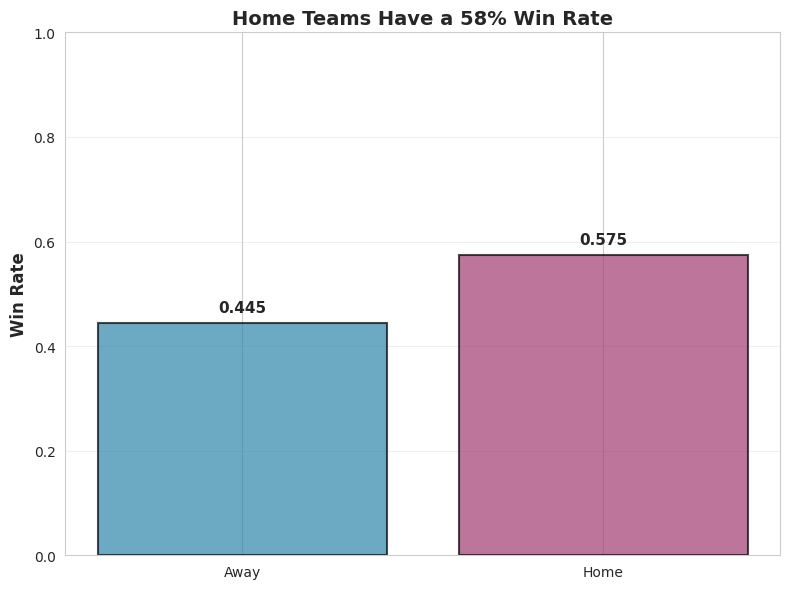


HOME vs AWAY STATISTICS
Home Team Win Rate: 0.575
Away Team Win Rate: 0.445
Home Court Advantage: 0.130


In [5]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# Home vs Away Analysis
home_away_stats = df.groupby('Is_Home')['Result'].agg(['count', 'sum', 'mean']).reset_index()
home_away_stats.columns = ['Is_Home', 'Total_Games', 'Wins', 'Win_Rate']
home_away_stats['Location'] = home_away_stats['Is_Home'].map({1: 'Home', 0: 'Away'})

# Create single plot
plt.figure(figsize=(8, 6))

# Bar chart: Win Rate
plt.bar(home_away_stats['Location'], home_away_stats['Win_Rate'],
        color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Win Rate', fontsize=12, fontweight='bold')
plt.title('Home Teams Have a 58% Win Rate', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, (loc, rate) in enumerate(zip(home_away_stats['Location'], home_away_stats['Win_Rate'])):
    plt.text(i, rate + 0.02, f'{rate:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*50)
print("HOME vs AWAY STATISTICS")
print("="*50)
print(f"Home Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0]:.3f}")
print(f"Away Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print(f"Home Court Advantage: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0] - home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print("="*50)

/tmp/ipython-input-4170300842.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()


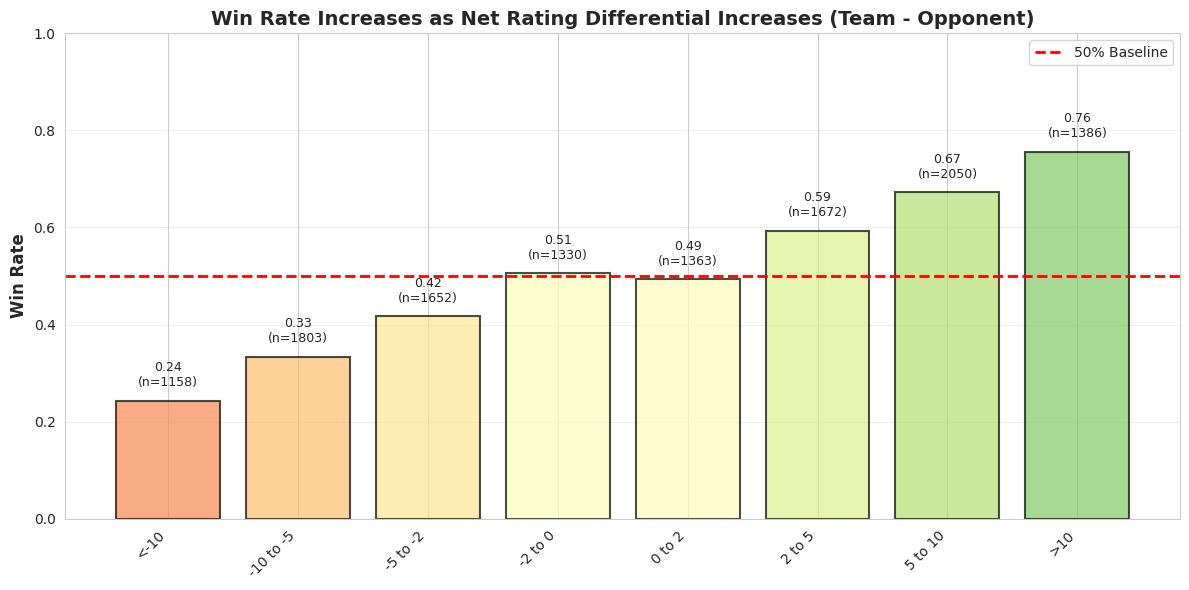


NET RATING DIFFERENTIAL ANALYSIS
Mean NetRtg_Diff for Wins: 2.85
Mean NetRtg_Diff for Losses: -2.07
Correlation (NetRtg_Diff vs Result): 0.301


In [6]:
# Filter out NaN values for NetRtg_Diff
df_clean = df.dropna(subset=['NetRtg_Diff', 'Result']).copy()

# Create bins for NetRtg_Diff
df_clean['NetRtg_Diff_Bin'] = pd.cut(df_clean['NetRtg_Diff'],
                                     bins=[-np.inf, -10, -5, -2, 0, 2, 5, 10, np.inf],
                                     labels=['<-10', '-10 to -5', '-5 to -2', '-2 to 0',
                                            '0 to 2', '2 to 5', '5 to 10', '>10'])

# Calculate win rate by bin
netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()
netrtg_analysis.columns = ['NetRtg_Diff_Bin', 'Total_Games', 'Wins', 'Win_Rate']

# Create visualization
plt.figure(figsize=(12, 6))

# Win rate by NetRtg_Diff bin
plt.bar(range(len(netrtg_analysis)), netrtg_analysis['Win_Rate'],
        color=plt.cm.RdYlGn(netrtg_analysis['Win_Rate']),
        alpha=0.7, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(netrtg_analysis)), netrtg_analysis['NetRtg_Diff_Bin'], rotation=45, ha='right')
plt.ylabel('Win Rate', fontsize=12, fontweight='bold')
plt.title('Win Rate Increases as Net Rating Differential Increases (Team - Opponent)', fontsize=14, fontweight='bold')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='50% Baseline')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.legend()
for i, (rate, count) in enumerate(zip(netrtg_analysis['Win_Rate'], netrtg_analysis['Total_Games'])):
    plt.text(i, rate + 0.03, f'{rate:.2f}\n(n={count})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "="*50)
print("NET RATING DIFFERENTIAL ANALYSIS")
print("="*50)
print(f"Mean NetRtg_Diff for Wins: {df_clean[df_clean['Result']==1]['NetRtg_Diff'].mean():.2f}")
print(f"Mean NetRtg_Diff for Losses: {df_clean[df_clean['Result']==0]['NetRtg_Diff'].mean():.2f}")
print(f"Correlation (NetRtg_Diff vs Result): {df_clean['NetRtg_Diff'].corr(df_clean['Result']):.3f}")
print("="*50)

Visualizations created with help from Cursor (Model: Claude Sonnet 4.5)

## **3. Feature Preparation**

Prepare the feature matrix and target variables for model training.

In [7]:
df.columns.tolist()

['Season',
 'Date',
 'Team',
 'Opponent',
 'Is_Home',
 'Game_Number_Team',
 'Game_Number_Opp',
 'Team_ORtg_avg',
 'Team_DRtg_avg',
 'Team_NetRtg_avg',
 'Team_Pace_avg',
 'Team_WinPct_avg',
 'Team_eFG%_avg',
 'Team_TOV%_avg',
 'Team_ORB%_avg',
 'Team_FT/FGA_avg',
 'Team_TS%_avg',
 'Team_TRB%_avg',
 'Team_AST%_avg',
 'Team_STL%_avg',
 'Team_BLK%_avg',
 'Team_NetRtg_last5',
 'Team_NetRtg_last10',
 'Team_WinPct_last5',
 'Team_WinPct_last10',
 'Team_Points_For_avg',
 'Team_Points_Against_avg',
 'Team_Current_Win_Streak',
 'Team_Current_Loss_Streak',
 'Team_Home_WinPct',
 'Team_Away_WinPct',
 'Team_Days_Rest',
 'Team_Is_BackToBack',
 'Opp_ORtg_avg',
 'Opp_DRtg_avg',
 'Opp_NetRtg_avg',
 'Opp_Pace_avg',
 'Opp_WinPct_avg',
 'Opp_eFG%_avg',
 'Opp_TOV%_avg',
 'Opp_ORB%_avg',
 'Opp_FT/FGA_avg',
 'Opp_TS%_avg',
 'Opp_TRB%_avg',
 'Opp_AST%_avg',
 'Opp_STL%_avg',
 'Opp_BLK%_avg',
 'Opp_NetRtg_last5',
 'Opp_NetRtg_last10',
 'Opp_WinPct_last5',
 'Opp_WinPct_last10',
 'Opp_Points_For_avg',
 'Opp_Points_

In [8]:
# Define columns to exclude from features
leak_cols = ['Result', 'Team_Score', 'Opp_Score', 'OT']  # Target leakage
id_cols = ['Season', 'Date', 'Team', 'Opponent']  # Identifiers, not predictive

# Prepare features and targets
X = df.drop(columns=[c for c in (leak_cols + id_cols) if c in df.columns]).copy()
y = df['Result'].astype(int)  # Binary target for classification

# Get unique seasons for time-series cross-validation
seasons = sorted(df['Season'].unique())

print(f"Seasons in dataset: {seasons}")
print(f"Total games: {len(df)}")
print(f"Features: {len(X.columns)}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Seasons in dataset: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Total games: 12590
Features: 70

Feature columns:
['Is_Home', 'Game_Number_Team', 'Game_Number_Opp', 'Team_ORtg_avg', 'Team_DRtg_avg', 'Team_NetRtg_avg', 'Team_Pace_avg', 'Team_WinPct_avg', 'Team_eFG%_avg', 'Team_TOV%_avg', 'Team_ORB%_avg', 'Team_FT/FGA_avg', 'Team_TS%_avg', 'Team_TRB%_avg', 'Team_AST%_avg', 'Team_STL%_avg', 'Team_BLK%_avg', 'Team_NetRtg_last5', 'Team_NetRtg_last10', 'Team_WinPct_last5', 'Team_WinPct_last10', 'Team_Points_For_avg', 'Team_Points_Against_avg', 'Team_Current_Win_Streak', 'Team_Current_Loss_Streak', 'Team_Home_WinPct', 'Team_Away_WinPct', 'Team_Days_Rest', 'Team_Is_BackToBack', 'Opp_ORtg_avg', 'Opp_DRtg_avg', 'Opp_NetRtg_avg', 'Opp_Pace_avg', 'Opp_WinPct_avg', 'Opp_eFG%_avg', 'Opp_TOV%_avg', 'Opp_ORB%_avg', 'Opp_FT/FGA_avg', 'Opp_TS%_avg', 'Opp_TRB%_avg', 'Opp_AST%_avg', 'Opp_STL%_avg', 'Opp_BLK%_avg', 'Opp_NetRtg_la

## **4. XGBoost Classifier Model**

Train an XGBoost classifier using rolling season splits for time-series cross-validation.

**Key features:**
- Rolling season splits: Train on historical seasons, test on future season
- Sample weighting: Exponential decay gives more weight to recent seasons
- Early stopping: Prevents overfitting using validation set
- Minimum 5 seasons of training data before making predictions

In [9]:
results = []

# Rolling season splits setup
min_train_seasons = 5  # Need at least 5 seasons for initial training
start_test_idx = min_train_seasons
DECAY_FACTOR = 0.10  # Recency weighting decay factor

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season}")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train = y.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test = y.loc[test_idx].copy()

    # Calculate sample weights: exponential decay for recency weighting
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight

    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost parameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub = y.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val = y.loc[val_idx].copy()

        # Calculate weights for subtrain set
        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_clf = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_clf.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        # Retrain on all training seasons with best_n_estimators
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    proba = booster_clf.predict(dtest)
    preds = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  ROC-AUC:  {auc:.3f}")

    results.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })



Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20'] → Test on 2020-21
  Season weights: {'2015-16': 0.6, '2016-17': 0.7, '2017-18': 0.8, '2018-19': 0.9, '2019-20': 1.0}
  Using 2019-20 as validation set for early stopping...
  Early stopping at 102 rounds
  Best n_estimators: 102
  Accuracy: 0.630
  ROC-AUC:  0.677

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21'] → Test on 2021-22
  Season weights: {'2015-16': 0.5, '2016-17': 0.6, '2017-18': 0.7, '2018-19': 0.8, '2019-20': 0.9, '2020-21': 1.0}
  Using 2020-21 as validation set for early stopping...
  Early stopping at 128 rounds
  Best n_estimators: 128
  Accuracy: 0.633
  ROC-AUC:  0.677

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22'] → Test on 2022-23
  Season weights: {'2015-16': 0.3999999999999999, '2016-17': 0.5, '2017-18': 0.6, '2018-19': 0.7, '2019-20': 0.8, '2020-21': 0.9, '2021-22': 1.0}
  Using 2021-22 as validation set for early stopping...
  E

In [14]:
# Classifier Results
results_df = pd.DataFrame(results)

print("="*70)
print("CLASSIFIER MODEL RESULTS")
print("="*70)
display(results_df)

print("\n" + "-"*70)
print(f"Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print("="*70)

CLASSIFIER MODEL RESULTS


,Train_Seasons,Test_Season,Best_n_estimators,Accuracy,ROC_AUC
0,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2020-21,102,0.629630,0.677441
1,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2021-22,128,0.632520,0.677406
2,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2022-23,82,0.616260,0.659097
3,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2023-24,239,0.638211,0.688530
4,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2024-25,102,0.652033,0.697613
5,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2025-26,127,0.639935,0.697893



----------------------------------------------------------------------
Average Accuracy: 0.635
Average ROC-AUC:  0.683


## **5. XGBoost Regressor Model**

Train an XGBoost regressor to predict point differential (Team_Score - Opp_Score).

**Key features:**
- Predicts point differential instead of binary outcome
- Converts predictions to win/loss (point diff > 0 = win)
- Same rolling season splits and sample weighting as classifier
- Provides regression metrics (RMSE, MAE, R²) in addition to classification metrics

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create point differential target
y_regression = (df['Team_Score'] - df['Opp_Score']).astype(float)
y_binary = df['Result'].astype(int)

print(f"Point differential range: [{y_regression.min():.1f}, {y_regression.max():.1f}]")

results_regression = []

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season} (REGRESSION)")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train_reg = y_regression.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test_reg = y_regression.loc[test_idx].copy()
    y_test_binary = y_binary.loc[test_idx].copy()

    # Calculate sample weights (same as classifier)
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight

    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost regression parameters
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub_reg = y_regression.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val_reg = y_regression.loc[val_idx].copy()

        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub_reg, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val_reg)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_reg = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_reg.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    point_diff_pred = booster_reg.predict(dtest)
    win_pred = (point_diff_pred > 0).astype(int)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, point_diff_pred))
    mae = mean_absolute_error(y_test_reg, point_diff_pred)
    r2 = r2_score(y_test_reg, point_diff_pred)

    # Classification metrics
    acc = accuracy_score(y_test_binary, win_pred)
    scale = 10.0
    proba_from_diff = 1 / (1 + np.exp(-point_diff_pred / scale))
    auc = roc_auc_score(y_test_binary, proba_from_diff)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Regression: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    print(f"  Classification: Accuracy={acc:.3f}, ROC-AUC={auc:.3f}")

    results_regression.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "RMSE": float(rmse),
        "MAE": float(mae),
        "R2": float(r2),
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })


Point differential range: [-59.0, 73.0]

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20'] → Test on 2020-21 (REGRESSION)
  Season weights: {'2015-16': 0.6, '2016-17': 0.7, '2017-18': 0.8, '2018-19': 0.9, '2019-20': 1.0}
  Using 2019-20 as validation set for early stopping...
  Early stopping at 120 rounds
  Best n_estimators: 120
  Regression: RMSE=14.275, MAE=11.235, R²=0.119
  Classification: Accuracy=0.624, ROC-AUC=0.669

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21'] → Test on 2021-22 (REGRESSION)
  Season weights: {'2015-16': 0.5, '2016-17': 0.6, '2017-18': 0.7, '2018-19': 0.8, '2019-20': 0.9, '2020-21': 1.0}
  Using 2020-21 as validation set for early stopping...
  Early stopping at 124 rounds
  Best n_estimators: 124
  Regression: RMSE=14.340, MAE=11.340, R²=0.131
  Classification: Accuracy=0.621, ROC-AUC=0.678

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22'] → Test on 2022-23 (REGRESSION)
  Seas

In [11]:
# Regression Model Results
results_regression_df = pd.DataFrame(results_regression)

print("="*70)
print("REGRESSION MODEL RESULTS")
print("="*70)
display(results_regression_df)

print("\n" + "-"*70)
print("Regression Metrics:")
print(f"  Average RMSE: {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:  {results_regression_df['MAE'].mean():.3f} points")
print(f"  Average R²:   {results_regression_df['R2'].mean():.3f}")
print("\nClassification Metrics (from point diff > 0):")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print("="*70)

REGRESSION MODEL RESULTS


,Train_Seasons,Test_Season,Best_n_estimators,RMSE,MAE,R2,Accuracy,ROC_AUC
0,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2020-21,120,14.275124,11.235030,0.118718,0.624074,0.668989
1,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2021-22,124,14.339633,11.340103,0.131301,0.621138,0.678227
2,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2022-23,124,13.033998,10.305274,0.118375,0.618699,0.656597
3,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2023-24,122,14.373858,11.212272,0.165878,0.647967,0.707224
4,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2024-25,98,14.340034,11.241474,0.175800,0.646341,0.705255
5,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2025-26,126,14.124772,11.050132,0.143626,0.648118,0.701354



----------------------------------------------------------------------
Regression Metrics:
  Average RMSE: 14.081 points
  Average MAE:  11.064 points
  Average R²:   0.142

Classification Metrics (from point diff > 0):
  Average Accuracy: 0.634
  Average ROC-AUC:  0.686


## **6. Results Comparison**

Compare the performance of the classifier and regressor models.

In [15]:
# Model Comparison
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"\nClassifier Model:")
print(f"  Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print(f"\nRegressor Model:")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print(f"  Average RMSE:     {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:      {results_regression_df['MAE'].mean():.3f} points")
print(f"\nBest Model for Win Prediction:")
if results_df['Accuracy'].mean() > results_regression_df['Accuracy'].mean():
    print("  → Classifier (higher accuracy)")
else:
    print("  → Regressor (higher accuracy)")
print("="*70)

MODEL COMPARISON

Classifier Model:
  Average Accuracy: 0.635
  Average ROC-AUC:  0.683

Regressor Model:
  Average Accuracy: 0.634
  Average ROC-AUC:  0.686
  Average RMSE:     14.081 points
  Average MAE:      11.064 points

Best Model for Win Prediction:
  → Classifier (higher accuracy)


## **7. Feature Importance**

Analyze which features contribute most to the model predictions.

### Classifier Feature Importance

In [16]:
# Classifier feature importance
score_clf = booster_clf.get_score(importance_type="gain")
fi_clf = pd.Series(score_clf).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_clf) > 0 and str(fi_clf.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_clf.index = fi_clf.index.map(feature_map)

print("Top 20 Features - Classifier Model:")
display(fi_clf.head(20))

Top 20 Features - Classifier Model:


,0
NetRtg_Diff,59.541306
Is_Home,29.269011
WinPct_Diff,28.565538
NetRtg_Diff_last10,18.135841
Team_Home_WinPct,15.881671
Opp_Home_WinPct,11.044890
Opp_Away_WinPct,9.119130
ORtg_Diff,9.084752
Game_Number_Opp,8.930152
Team_Away_WinPct,8.627123


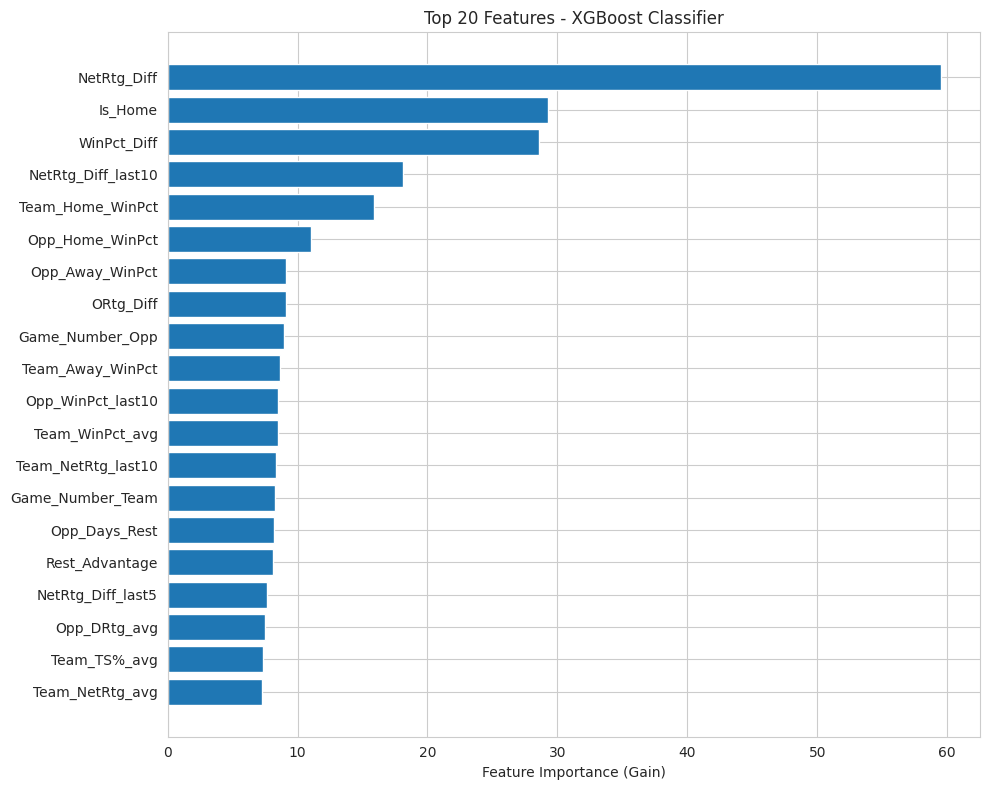

In [17]:
# Visualize classifier feature importance
fi_clf_top20 = fi_clf.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(len(fi_clf_top20)), fi_clf_top20.values)
plt.yticks(range(len(fi_clf_top20)), fi_clf_top20.index)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Features - XGBoost Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Regressor Feature Importance

In [18]:
# Regressor feature importance
score_reg = booster_reg.get_score(importance_type="gain")
fi_reg = pd.Series(score_reg).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_reg) > 0 and str(fi_reg.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_reg.index = fi_reg.index.map(feature_map)

print("Top 20 Features - Regressor Model:")
display(fi_reg.head(20))

Top 20 Features - Regressor Model:


,0
NetRtg_Diff,17580.501953
WinPct_Diff,8935.803711
NetRtg_Diff_last10,3736.474854
Team_Home_WinPct,3261.647705
Opp_Home_WinPct,2968.298584
Is_Home,2851.761719
Team_Away_WinPct,2345.407471
Game_Number_Opp,2316.881592
Opp_NetRtg_avg,2171.454346
Opp_Away_WinPct,1982.210205


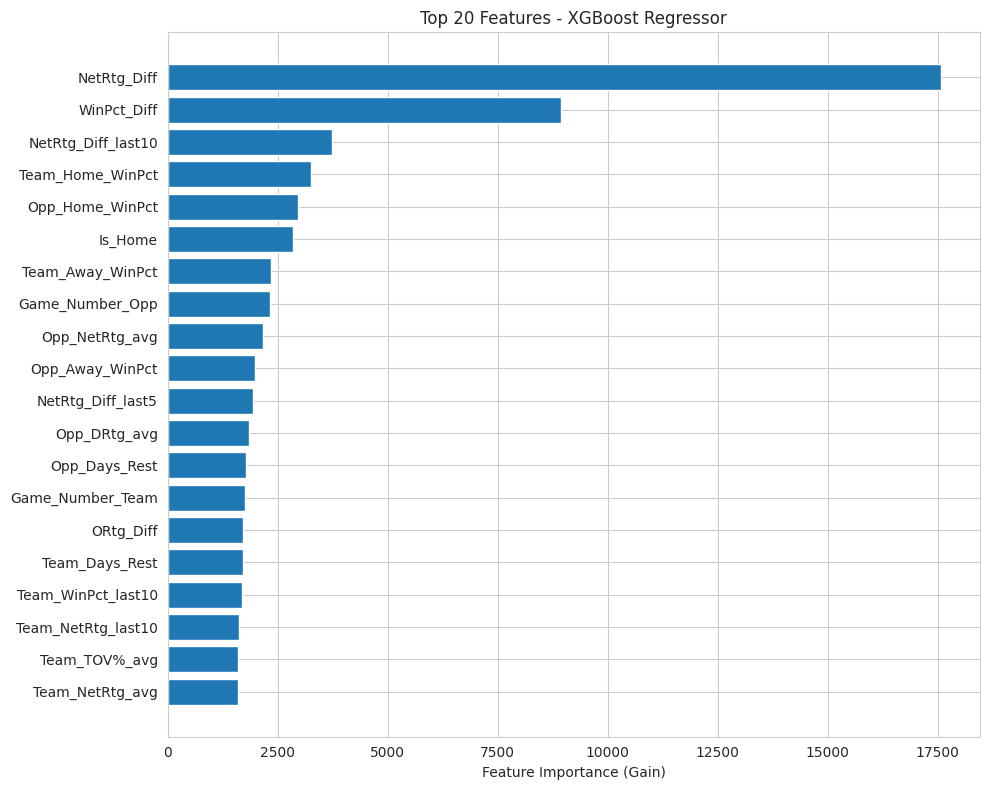

In [19]:
# Visualize regressor feature importance
fi_reg_top20 = fi_reg.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(len(fi_reg_top20)), fi_reg_top20.values)
plt.yticks(range(len(fi_reg_top20)), fi_reg_top20.index)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Features - XGBoost Regressor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()